In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

: 

In [2]:
df=pd.read_csv("heart.csv")

In [15]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


* age: The age of the patient.
* sex: Gender of the patient (0: female, 1: male).
* cp: Type of chest pain.
* trestbps: Resting blood pressure.
* chol: Serum cholesterol.
* fbs: Fasting blood sugar > 120 mg/dl.
* restecg: Resting electrocardiographic results.
* thalach: Maximum heart rate achieved.
* exang: Exercise induced angina.
* oldpeak: ST depression induced by exercise relative to rest

In [5]:
df.isnull().any()

,0
age,False
sex,False
cp,False
trestbps,False
chol,False
fbs,False
restecg,False
thalach,False
exang,False
oldpeak,False


In [6]:
df.shape

(303, 14)

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


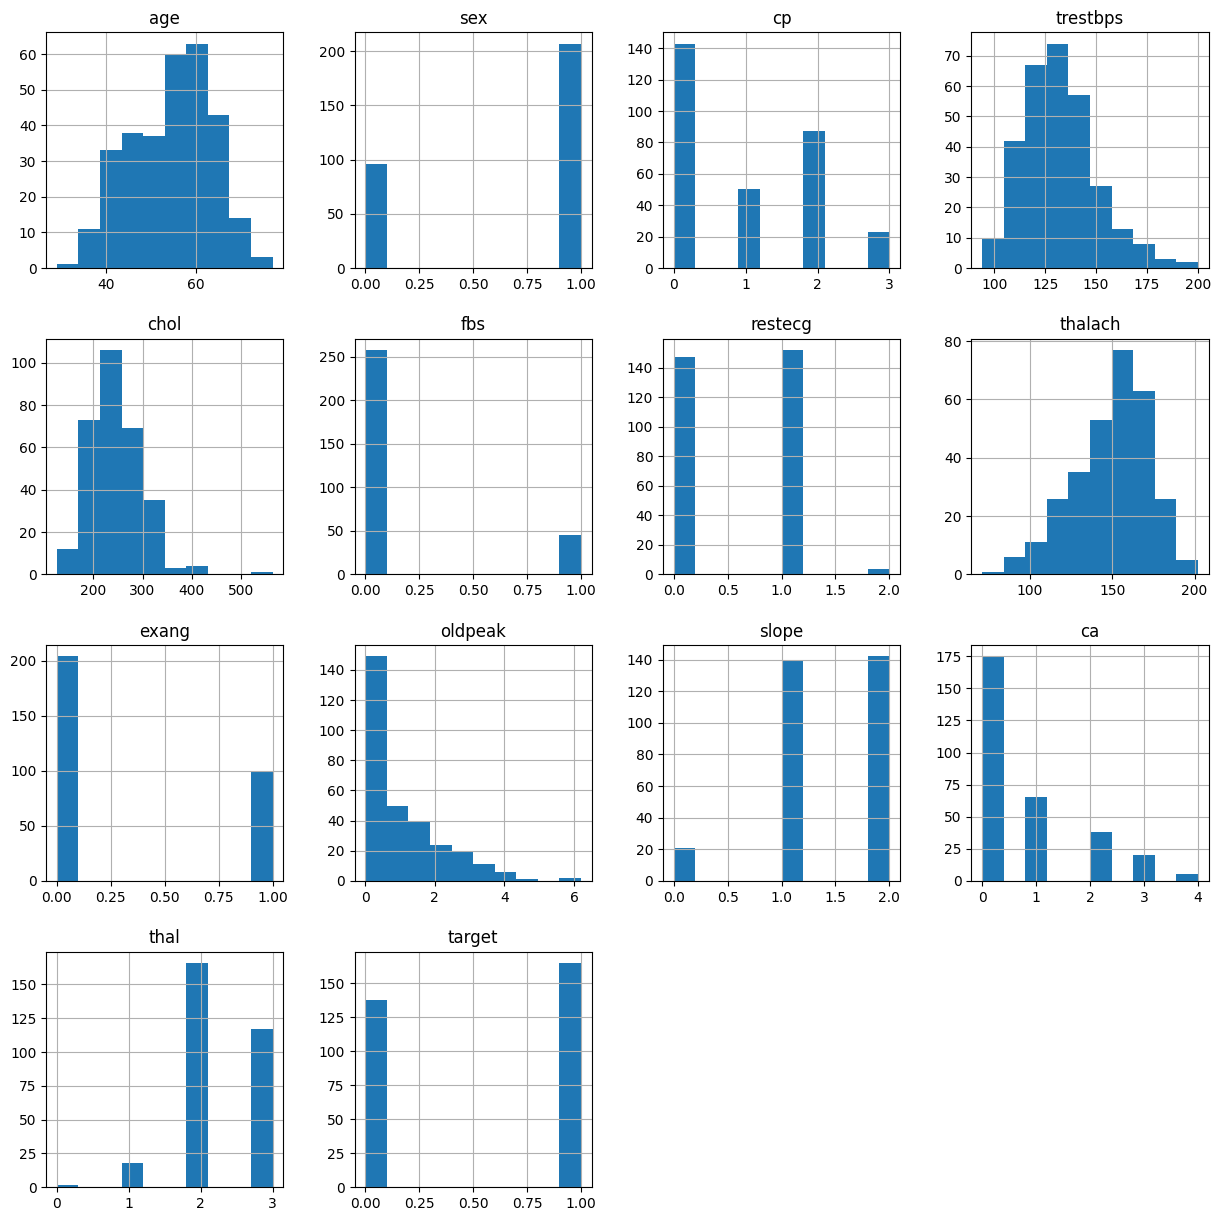

In [9]:
# Plotting histogram for the entire dataset
fig = plt.figure(figsize = (15,15))
ax = fig.gca()
g = df.hist(ax=ax)

Text(0, 0.5, 'Count')

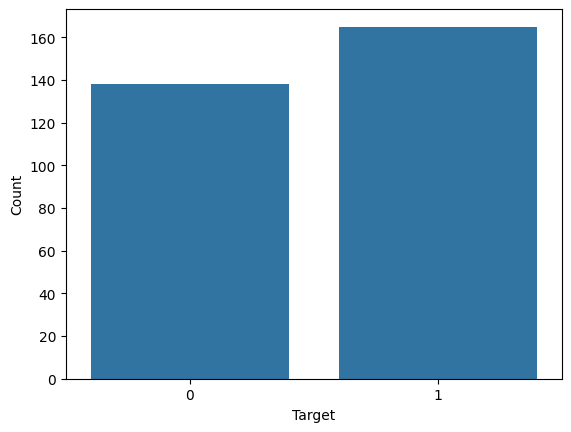

In [10]:
# Visualization to check if the dataset is balanced or not
g = sns.countplot(x='target', data=df)
plt.xlabel('Target')
plt.ylabel('Count')

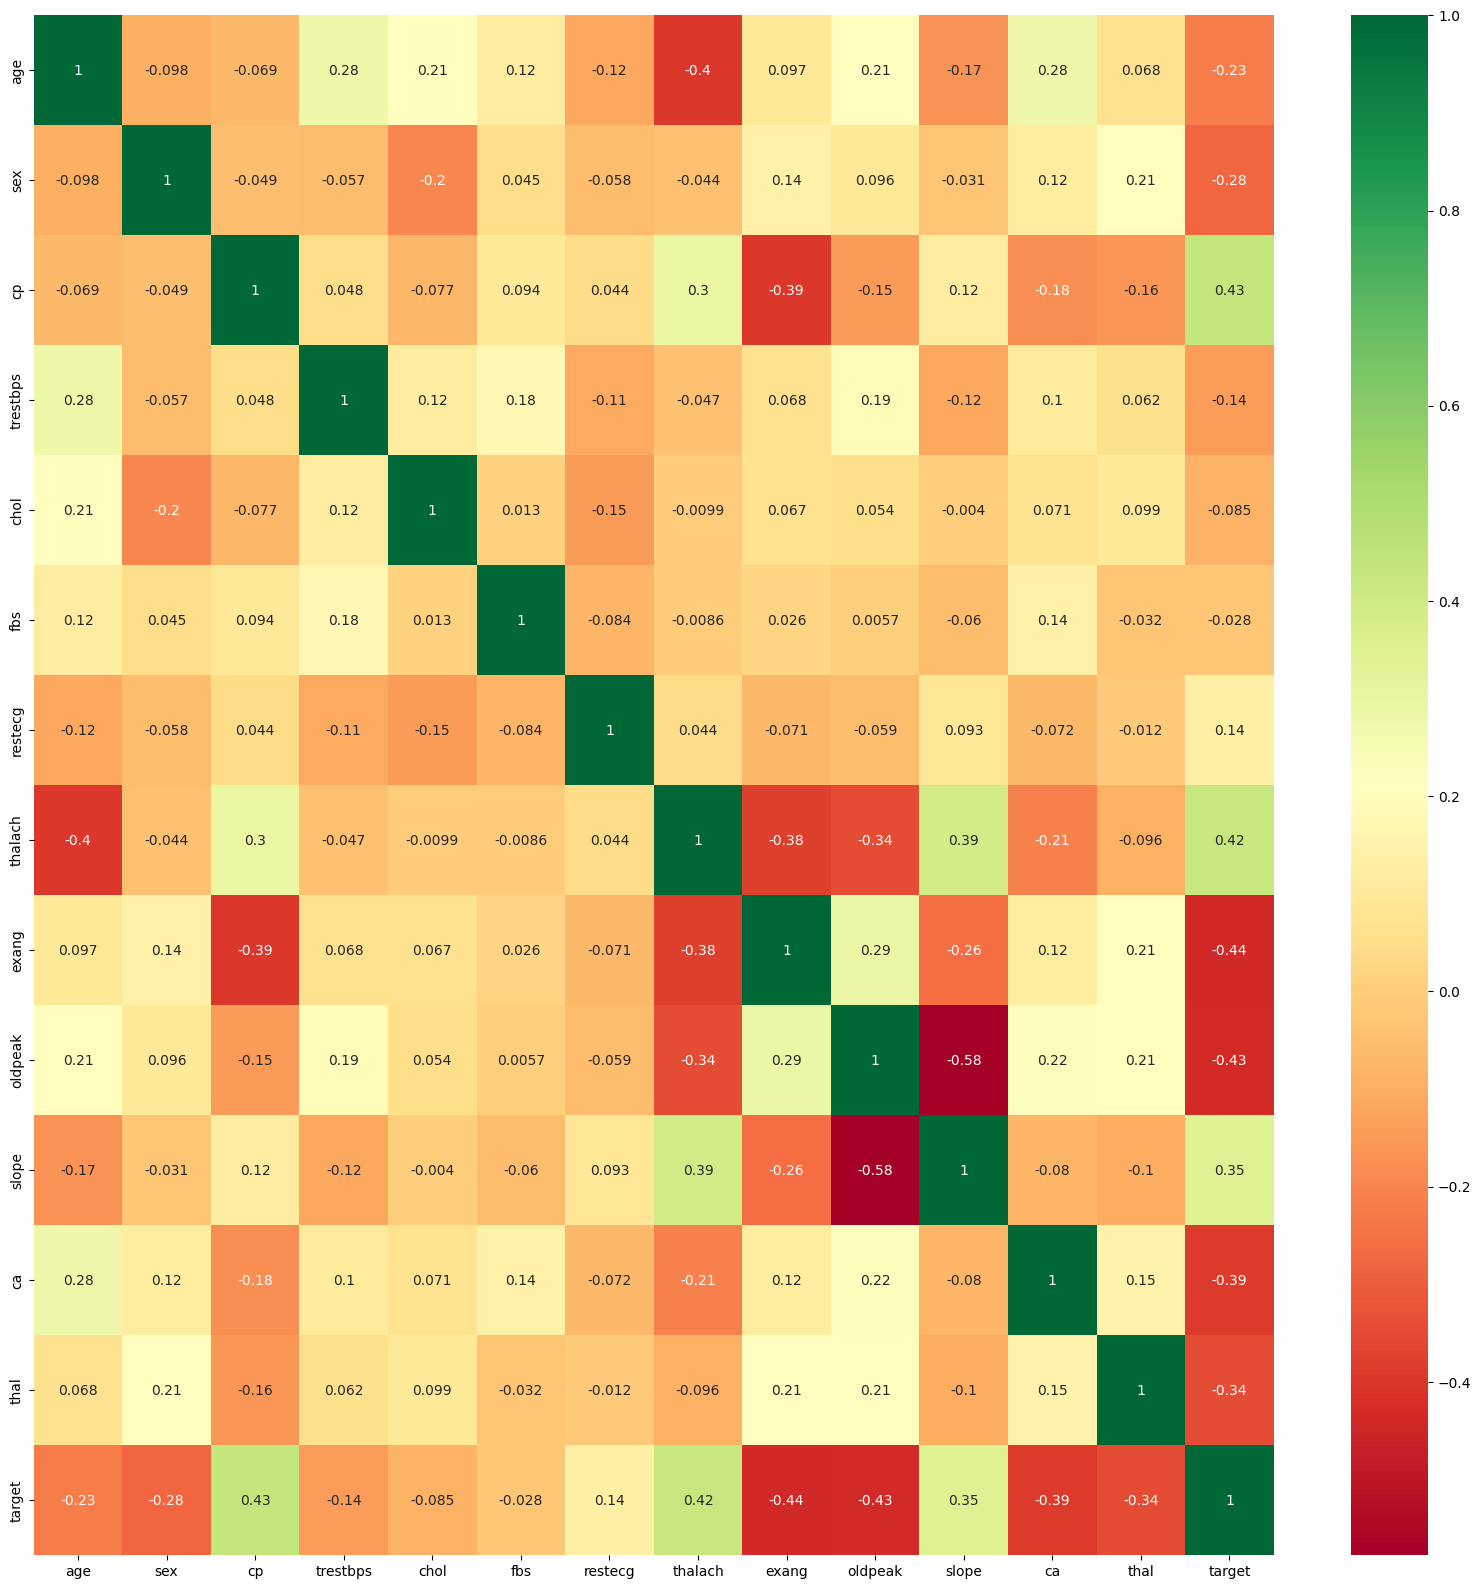

In [12]:
corr_matrix=df.corr()
top_corr_features=corr_matrix.index
plt.figure(figsize=(20,20))
g=sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [13]:
dataset=pd.get_dummies(df,columns=['sex','cp','fbs','restecg','exang','slope','ca','thal'])

In [14]:
dataset.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_0',
       'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'fbs_0', 'fbs_1', 'restecg_0',
       'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'slope_0', 'slope_1',
       'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1',
       'thal_2', 'thal_3'],
      dtype='object')

In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
columns_to_scale=['age','trestbps','chol','thalach','oldpeak']
dataset[columns_to_scale]=sc.fit_transform(dataset[columns_to_scale])

In [18]:
dataset.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,1,True,False,False,True,...,True,True,False,False,False,False,False,False,True,False
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,1,False,True,False,True,...,True,True,False,False,False,False,False,False,True,False
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,1,True,False,True,False,...,True,True,False,False,False,False,False,False,True,False


In [21]:
dataset.shape

(303, 31)

In [19]:
X=dataset.drop('target',axis=1)
y=dataset['target']

In [20]:
import tensorflow as tf

In [22]:
model_1=tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation='relu',input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(1,activation='softmax')
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mae",
    metrics=['accuracy']
)

model_1.fit(X,y,epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5703 - loss: 0.4297
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5349 - loss: 0.4651 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5405 - loss: 0.4595 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5298 - loss: 0.4702 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5582 - loss: 0.4418 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5175 - loss: 0.4825 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5352 - loss: 0.4648 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5454 - loss: 0.4546 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5241 - loss: 0.4759 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5703 - loss: 0.4297 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5368 - loss: 0.4632 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step -

In [23]:
model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(128,input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1,activation='softmax')
])

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mae",
    metrics=['accuracy']
)

model_2.fit(X,y,epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5605 - loss: 0.4395
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5740 - loss: 0.4260 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5142 - loss: 0.4858 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5403 - loss: 0.4597 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5548 - loss: 0.4452  
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5369 - loss: 0.4631  
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5682 - loss: 0.4318 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5355 - loss: 0.4645 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5355 - loss: 0.4645 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5391 - loss: 0.4609 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5404 - loss: 0.4596 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

In [26]:
model_3=tf.keras.Sequential([
    tf.keras.layers.Dense(128,input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1,activation='softmax')
])

model_3.compile(
    optimizer=tf.keras.optimizers.SGD(),
    loss="mae",
    metrics=['accuracy']
)

model_3.fit(X,y,epochs=100,verbose=2)

Epoch 1/100
10/10 - 1s - 51ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 2/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 3/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 4/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 5/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 6/100
10/10 - 0s - 13ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 7/100
10/10 - 0s - 7ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 8/100
10/10 - 0s - 13ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 9/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 10/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 11/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 12/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 13/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 14/100
10/10 - 0s - 6ms/step - accuracy: 0.5446 - loss: 0.4554
Epoch 15/100
10/10 - 0s - 6ms/step - acc

In [25]:
model_3.evaluate(X,y)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8093 - loss: 0.1907      


[0.4554455578327179, 0.5445544719696045]

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),
    tf.keras.layers.Dropout(0.3),  # Add dropout for regularization
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0009), # Lower learning rate
    loss='binary_crossentropy', # Use binary crossentropy for binary classification
    metrics=['accuracy']
)

history = model_4.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test)) # Increased epochs, added validation

loss, accuracy = model_4.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6786 - loss: 0.6450 - val_accuracy: 0.8852 - val_loss: 0.5189
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8249 - loss: 0.5232 - val_accuracy: 0.8689 - val_loss: 0.4142
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8151 - loss: 0.4556 - val_accuracy: 0.8689 - val_loss: 0.3597
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8561 - loss: 0.3726 - val_accuracy: 0.8852 - val_loss: 0.3368
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8244 - loss: 0.4048 - val_accuracy: 0.9016 - val_loss: 0.3278
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8616 - loss: 0.3240 - val_accuracy: 0.9016 - val_loss: 0.3278
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8531 - loss: 0.3315 - val_accuracy: 0.8689 - val_loss: 0.3508
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8667 - loss: 0.3103 - val_accuracy: 0.9016 - val_loss: 0.3337


In [33]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X.shape[1],)),
    tf.keras.layers.Dropout(0.4),  # Add dropout for regularization
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0009), # Lower learning rate
    loss='binary_crossentropy', # Use binary crossentropy for binary classification
    metrics=['accuracy']
)

history = model_4.fit(X_train, y_train, epochs=50,validation_data=(X_test, y_test)) # Increased epochs, added validat

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6769 - loss: 0.6542 - val_accuracy: 0.7869 - val_loss: 0.5522
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7664 - loss: 0.5869 - val_accuracy: 0.8525 - val_loss: 0.4769
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8186 - loss: 0.5132 - val_accuracy: 0.8525 - val_loss: 0.4192
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8319 - loss: 0.4376 - val_accuracy: 0.8689 - val_loss: 0.3767
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8227 - loss: 0.4308 - val_accuracy: 0.8852 - val_loss: 0.3496
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8369 - loss: 0.4095 - val_accuracy: 0.9016 - val_loss: 0.3389
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8560 - loss: 0.3888 - val_accuracy: 0.9016 - val_loss: 0.3309
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8483 - loss: 0.3606 - val_accuracy: 0.9016 - val_loss: 0.3261


In [35]:
def plot(history):

  history_dict = history.history

  # Plot Accuracy
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(history_dict['accuracy'], label='Train Accuracy', marker='o')
  plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', marker='o')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.title('Training vs Validation Accuracy')
  plt.legend()
  plt.grid(True)

  # Plot Loss
  plt.subplot(1, 2, 2)
  plt.plot(history_dict['loss'], label='Train Loss', marker='o')
  plt.plot(history_dict['val_loss'], label='Validation Loss', marker='o')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training vs Validation Loss')
  plt.legend()
  plt.grid(True)

  plt.show()

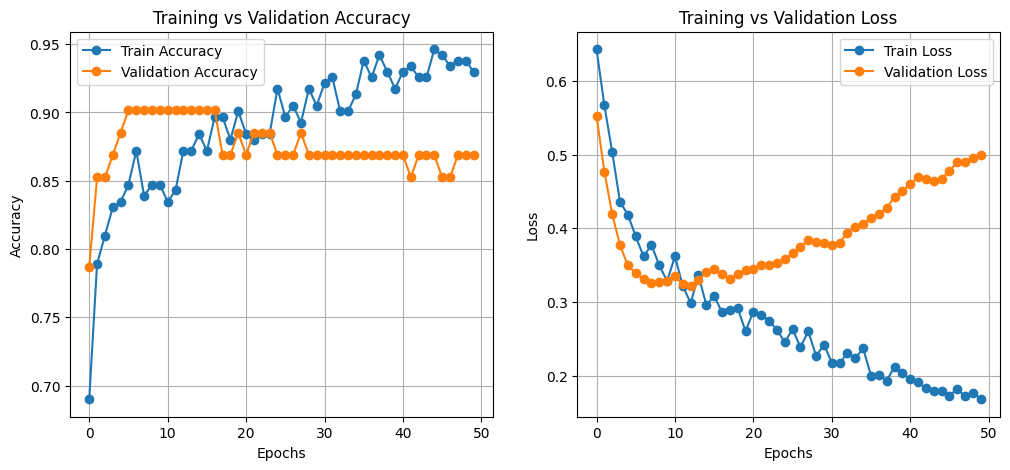

In [36]:
plot(history)

In [41]:
model_5= tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X.shape[1],)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_5.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_5.fit(X_train, y_train, epochs=100,validation_data=(X_test, y_test))

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5554 - loss: 0.6727 - val_accuracy: 0.8033 - val_loss: 0.5912
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7662 - loss: 0.5903 - val_accuracy: 0.8525 - val_loss: 0.5183
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7994 - loss: 0.5237 - val_accuracy: 0.8852 - val_loss: 0.4549
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7349 - loss: 0.5062 - val_accuracy: 0.8852 - val_loss: 0.4109
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7860 - loss: 0.4704 - val_accuracy: 0.8852 - val_loss: 0.3826
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8038 - loss: 0.4137 - val_accuracy: 0.8852 - val_loss: 0.3651
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8143 - loss: 0.4089 - val_accuracy: 0.8852 - val_loss: 0.3617
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8592 - loss: 0.3628 - val_accuracy: 0.8852 - val_loss:

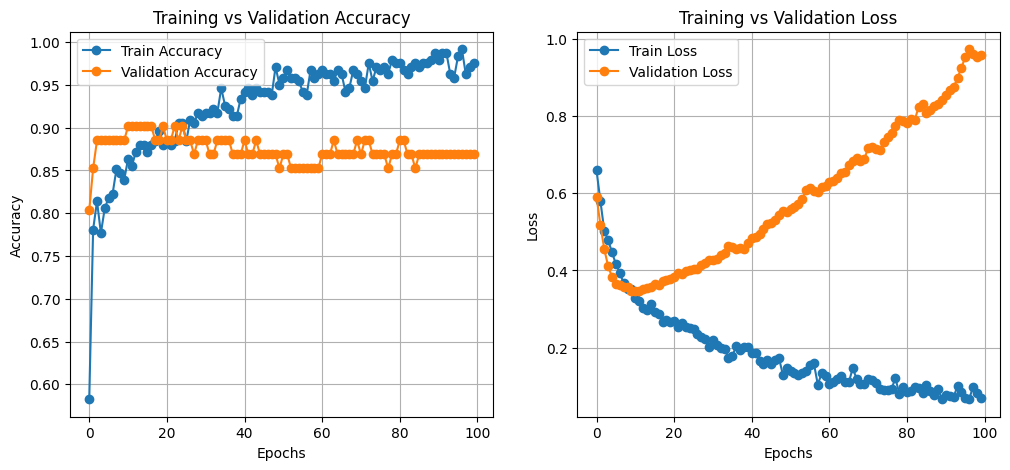

In [42]:
plot(history)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5998 - loss: 0.6669 - val_accuracy: 0.8852 - val_loss: 0.5708
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7727 - loss: 0.5736 - val_accuracy: 0.8852 - val_loss: 0.4986
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7595 - loss: 0.5346 - val_accuracy: 0.8852 - val_loss: 0.4439
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8276 - loss: 0.4804 - val_accuracy: 0.8689 - val_loss: 0.4015
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7884 - loss: 0.4740 - val_accuracy: 0.8689 - val_loss: 0.3735
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8016 - loss: 0.4473 - val_accuracy: 0.8852 - val_loss: 0.3566
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8319 - loss: 0.4038 - val_accuracy: 0.9016 - val_loss: 0.3411
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8121 - loss: 0.4250 - val_accuracy: 0.8852 - val_loss:

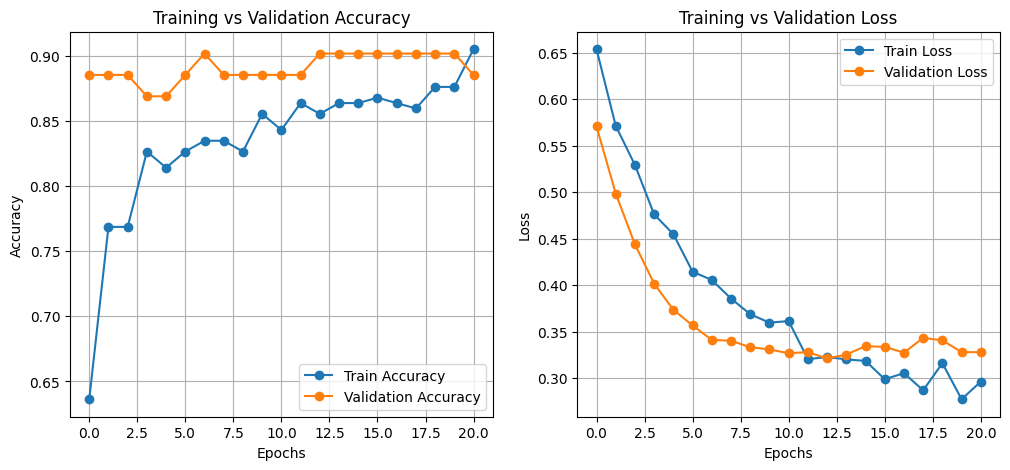

In [43]:
# prompt: make a model with callback

import tensorflow as tf

class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.9:
            print("\nReached 90% accuracy so cancelling training!")
            self.model.stop_training = True

# Assuming X_train, y_train, X_test, y_test are defined as in your provided code
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X.shape[1],)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_5.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_5.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test),
                      callbacks=[CustomCallback()]) # Add the custom callback here

plot(history) # Assuming 'plot' function is defined as in your provided code


In [51]:
import random

i=1
j=1
while i>0:

  random_index = random.randint(0, len(X_test) - 1)

  random_data_point = X_test.iloc[[random_index]]
  actual_label = y_test.iloc[random_index]

  # Make the prediction using model_5
  predicted_label = model_5.predict(random_data_point)
  predicted_label = (predicted_label > 0.5).astype(int)[0][0] # Convert probability to binary prediction


  print(f"Random Data Point Index: {random_index}")
  print(f"Actual Label: {actual_label}")
  print(f"Predicted Label: {predicted_label}")

  if predicted_label == actual_label:
    print(f" {j} Prediction is Correct!")
    j+=1
  else:
    print("Prediction is Incorrect.")
    break


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Random Data Point Index: 45
Actual Label: 0
Predicted Label: 0
 1 Prediction is Correct!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Random Data Point Index: 6
Actual Label: 1
Predicted Label: 1
 2 Prediction is Correct!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Random Data Point Index: 6
Actual Label: 1
Predicted Label: 1
 3 Prediction is Correct!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Random Data Point Index: 42
Actual Label: 1
Predicted Label: 1
 4 Prediction is Correct!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Random Data Point Index: 53
Actual Label: 1
Predicted Label: 1
 5 Prediction is Correct!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Random Data Point Index: 59
Actual Label: 0
Predicted Label: 0
 6 Prediction is Correct!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Random Data Point Index: 5
Actual Label: 1
Predicted Label: 1
 7 Prediction is Correct!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Random Data Point Index: 31
Actual Label: 0
Predicted Label: 0
 8 Prediction